# 🏠 Housing Price Prediction — Regresión Lineal Supervisada
## Machine Learning II · Análisis supervisado y optimización de predicciones

---

Este notebook desarrolla un modelo de regresión supervisada para predecir el precio de viviendas,  
aplicando preprocesamiento, visualización, entrenamiento y evaluación con scikit-learn.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Carga y análisis exploratorio (EDA) |
| 2️⃣ | Exploración visual — histograma, boxplot, pairplot, heatmap |
| 3️⃣ | Preprocesamiento — auditoría de tipos, OHE, escalado |
| 4️⃣ | División train/test |
| 5️⃣ | Regresión Lineal — entrenamiento y coeficientes |
| 6️⃣ | Evaluación — MSE, MAE, R², R² ajustado, CV K-Fold, Ridge/Lasso |
| 7️⃣ | Visualización de resultados y diagnóstico de residuos |
| 8️⃣ | Conclusiones |

> **Dataset:** `Housing.csv` — 545 registros · 13 columnas (7 categóricas + 6 numéricas)  
> **Objetivo:** predecir la variable `price` (continua) usando regresión lineal  
> **Ruta:** `/workspace/Housing.csv`


---
## 0. Importación de librerías y configuración


In [23]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

# ── Estilo global de gráficos ─────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

warnings.filterwarnings("ignore", category=UserWarning)

# ── Rutas ─────────────────────────────────────────────────────────────────────
INPUT_PATH = "workspace/Housing.csv"

print("✅ Librerías cargadas correctamente.")
print(f"📂 Ruta del dataset: {INPUT_PATH}")


✅ Librerías cargadas correctamente.
📂 Ruta del dataset: workspace/Housing.csv


---
## 1. Carga y Exploración de Datos (EDA)

### 1.1 Carga del dataset


In [24]:
df = pd.read_csv(INPUT_PATH)

print(f"📐 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\n📋 Columnas:")
for col in df.columns:
    print(f"  · {col:20s}  dtype={df[col].dtype}")


📐 Dimensiones: 545 filas × 13 columnas

📋 Columnas:
  · price                 dtype=int64
  · area                  dtype=int64
  · bedrooms              dtype=int64
  · bathrooms             dtype=int64
  · stories               dtype=int64
  · mainroad              dtype=str
  · guestroom             dtype=str
  · basement              dtype=str
  · hotwaterheating       dtype=str
  · airconditioning       dtype=str
  · parking               dtype=int64
  · prefarea              dtype=str
  · furnishingstatus      dtype=str


### 1.2 Primeras filas (`df.head()`)

In [25]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### 1.3 Información general y tipos de dato

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


### 1.4 Estadísticas descriptivas — variables numéricas

In [27]:
df.describe().round(2)

,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


### 1.5 Valores nulos e inconsistencias — estado actual y estrategia preventiva

Comprobamos si existen valores faltantes en el dataset actual. Aunque en `Housing.csv` no hay nulos,
se documenta explícitamente la estrategia de tratamiento para garantizar que el pipeline sea robusto
frente a versiones futuras del dataset o fuentes de datos externas.


In [28]:
# ── Diagnóstico de valores nulos ─────────────────────────────────────────────
nulos = df.isnull().sum()
print("🔍 Valores nulos por columna:")
print(nulos.to_string())
print(f"\n{'✅' if nulos.sum() == 0 else '⚠️'} Total de valores nulos: {nulos.sum()}")

# ── Estrategia de tratamiento para datos faltantes ────────────────────────────
print("\n" + "─"*65)
print("📋 Estrategia preventiva de imputación (pipeline productivo)\n")
print("  Si en el futuro apareciesen valores nulos, la estrategia sería:")
print()

estrategia = [
    ("area",            "Numérica continua",  "Imputar con la MEDIANA del train set",
     "Robusta frente a la asimetría de 'area'"),
    ("bedrooms",        "Discreta (conteo)",   "Imputar con la MODA del train set",
     "Valores enteros — la media generaría valores no enteros"),
    ("bathrooms",       "Discreta (conteo)",   "Imputar con la MODA del train set",  "ídem"),
    ("stories",         "Discreta (conteo)",   "Imputar con la MODA del train set",  "ídem"),
    ("parking",         "Discreta (conteo)",   "Imputar con la MODA del train set",  "ídem"),
    ("mainroad",        "Categórica binaria",  "Imputar con la MODA del train set",
     "Valor más frecuente preserva la distribución"),
    ("furnishingstatus","Categórica nominal",  "Imputar con la MODA del train set",
     "ídem para variables nominales"),
    ("price",           "Variable objetivo",   "DESCARTAR la fila",
     "No imputar el target — introduciría sesgo directo en el modelo"),
]

print(f"  {'Columna':<22} {'Tipo':<22} {'Estrategia':<38} Justificación")
print("  " + "─"*115)
for col, tipo, estrategia_, justif in estrategia:
    print(f"  {col:<22} {tipo:<22} {estrategia_:<38} {justif}")

print()
print("  💡 Implementación con SimpleImputer de scikit-learn:")
print("     from sklearn.impute import SimpleImputer")
print("     # Numéricas → mediana:")
print("     imp_num = SimpleImputer(strategy='median')")
print("     X_train[cols_escalar] = imp_num.fit_transform(X_train[cols_escalar])")
print("     X_test[cols_escalar]  = imp_num.transform(X_test[cols_escalar])")
print("     # Categóricas → moda:")
print("     imp_cat = SimpleImputer(strategy='most_frequent')")
print("     # (aplicar antes del OHE, sobre las columnas originales)")

# ── Variables categóricas
cols_cat = df.select_dtypes(include="object").columns.tolist()
print(f"\n📊 Variables categóricas encontradas: {cols_cat}")
for col in cols_cat:
    print(f"  · '{col}'  →  {df[col].unique().tolist()}")


🔍 Valores nulos por columna:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0

✅ Total de valores nulos: 0

─────────────────────────────────────────────────────────────────
📋 Estrategia preventiva de imputación (pipeline productivo)

  Si en el futuro apareciesen valores nulos, la estrategia sería:

  Columna                Tipo                   Estrategia                             Justificación
  ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  area                   Numérica continua      Imputar con la MEDIANA del train set   Robusta frente a la asimetría de 'area'
  bedrooms               Discreta (conteo)      Imputar con la MODA del train set      Valores enteros — la media g

C:\Users\macdu\AppData\Local\Temp\ipykernel_25132\3258072673.py:46: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = df.select_dtypes(include="object").columns.tolist()


---
## 2. Exploración Visual de los Datos

### 2.1 Histograma de `price`

Distribución de la variable objetivo para identificar su forma, concentración y posible asimetría.


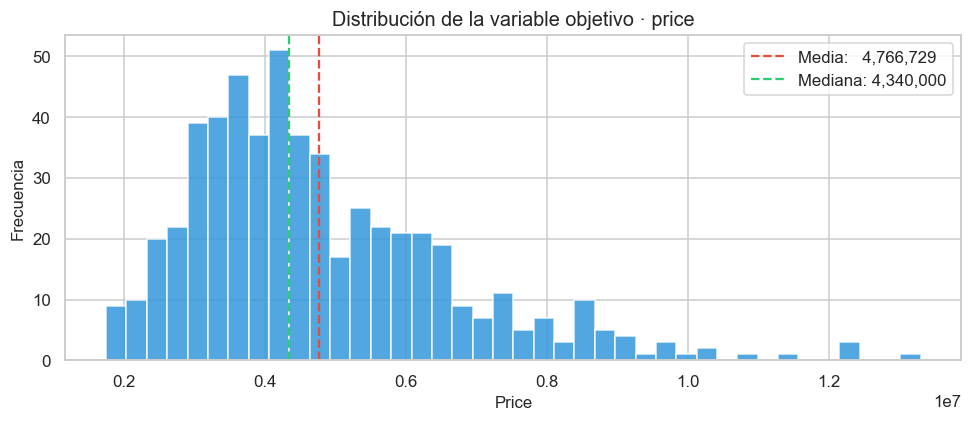

📊 Estadísticas de forma:
  Asimetría (skew):    1.212  — sesgada a la derecha (cola larga hacia valores altos)
  Curtosis (excess):   1.960  — distribución leptocúrtica (colas pesadas)
  Coef. de variación:  39.2%  — dispersión moderada

🔍 Interpretación:
  · La media (4,766,729) supera a la mediana (4,340,000),
    confirmando asimetría positiva: un subconjunto de viviendas muy caras jala la
    distribución hacia la derecha.
  · La mayor parte de las viviendas se concentra en el rango
    [3,430,000 – 5,740,000] (IQR del 50% central).
  · Esta asimetría sugiere explorar una transformación log(price) para
    modelos lineales, aunque en este ejercicio trabajaremos con la escala original.


In [29]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(df["price"], bins=40, color="#3498db", edgecolor="white", alpha=0.85)
ax.axvline(df["price"].mean(),   color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"Media:   {df['price'].mean():,.0f}")
ax.axvline(df["price"].median(), color="#2ecc71", linestyle="--", linewidth=1.5,
           label=f"Mediana: {df['price'].median():,.0f}")

ax.set_xlabel("Price")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de la variable objetivo · price")
ax.legend()
plt.tight_layout()
plt.show()

skew_val  = df["price"].skew()
kurt_val  = df["price"].kurtosis()
cv_val    = df["price"].std() / df["price"].mean() * 100
print(f"📊 Estadísticas de forma:")
print(f"  Asimetría (skew):    {skew_val:.3f}  — {'sesgada a la derecha (cola larga hacia valores altos)' if skew_val > 0.5 else 'aproximadamente simétrica'}")
print(f"  Curtosis (excess):   {kurt_val:.3f}  — {'distribución leptocúrtica (colas pesadas)' if kurt_val > 1 else 'distribución mesocúrtica (colas normales)'}")
print(f"  Coef. de variación:  {cv_val:.1f}%  — {'alta dispersión relativa' if cv_val > 50 else 'dispersión moderada'}")
print()
print("🔍 Interpretación:")
print(f"  · La media ({df['price'].mean():,.0f}) supera a la mediana ({df['price'].median():,.0f}),")
print(f"    confirmando asimetría positiva: un subconjunto de viviendas muy caras jala la")
print(f"    distribución hacia la derecha.")
print(f"  · La mayor parte de las viviendas se concentra en el rango")
print(f"    [{df['price'].quantile(0.25):,.0f} – {df['price'].quantile(0.75):,.0f}] (IQR del 50% central).")
print(f"  · Esta asimetría sugiere explorar una transformación log(price) para")
print(f"    modelos lineales, aunque en este ejercicio trabajaremos con la escala original.")


### 2.2 Boxplot de `price`

Identifica la presencia de valores atípicos y la dispersión de la variable objetivo.


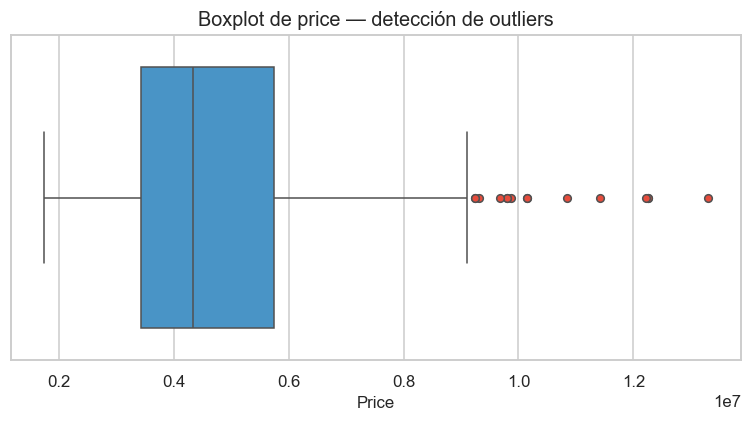

📊 IQR = 2,310,000   |   Límite inferior = -35,000   |   Límite superior = 9,205,000
🔴 Outliers detectados: 15 (2.8% del total)


In [30]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(x=df["price"], ax=ax, color="#3498db",
            flierprops=dict(marker="o", markerfacecolor="#e74c3c", markersize=5))
ax.set_xlabel("Price")
ax.set_title("Boxplot de price — detección de outliers")
plt.tight_layout()
plt.show()

# Cuantificar outliers con IQR
Q1, Q3 = df["price"].quantile([0.25, 0.75])
IQR = Q3 - Q1
n_outliers = ((df["price"] < Q1 - 1.5*IQR) | (df["price"] > Q3 + 1.5*IQR)).sum()
print(f"📊 IQR = {IQR:,.0f}   |   Límite inferior = {Q1 - 1.5*IQR:,.0f}   |   Límite superior = {Q3 + 1.5*IQR:,.0f}")
print(f"🔴 Outliers detectados: {n_outliers} ({n_outliers/len(df)*100:.1f}% del total)")


### 2.3 Pairplot de variables numéricas

Se generan dos versiones del pairplot:

- **Versión completa**: todas las variables numéricas — limitada a `MAX_PAIRPLOT_COLS` columnas y `MAX_PAIRPLOT_ROWS` filas para garantizar tiempos de renderizado razonables si el dataset creciera.
- **Versión focalizada**: únicamente las variables con `|correlación con price| ≥ UMBRAL_CORR` — análisis más denso y legible de los predictores más relevantes.


⚠️  Dataset > 500 filas → muestra de 500 filas para pairplot completo.
✅ 6 columnas numéricas — todas incluidas en el pairplot completo.


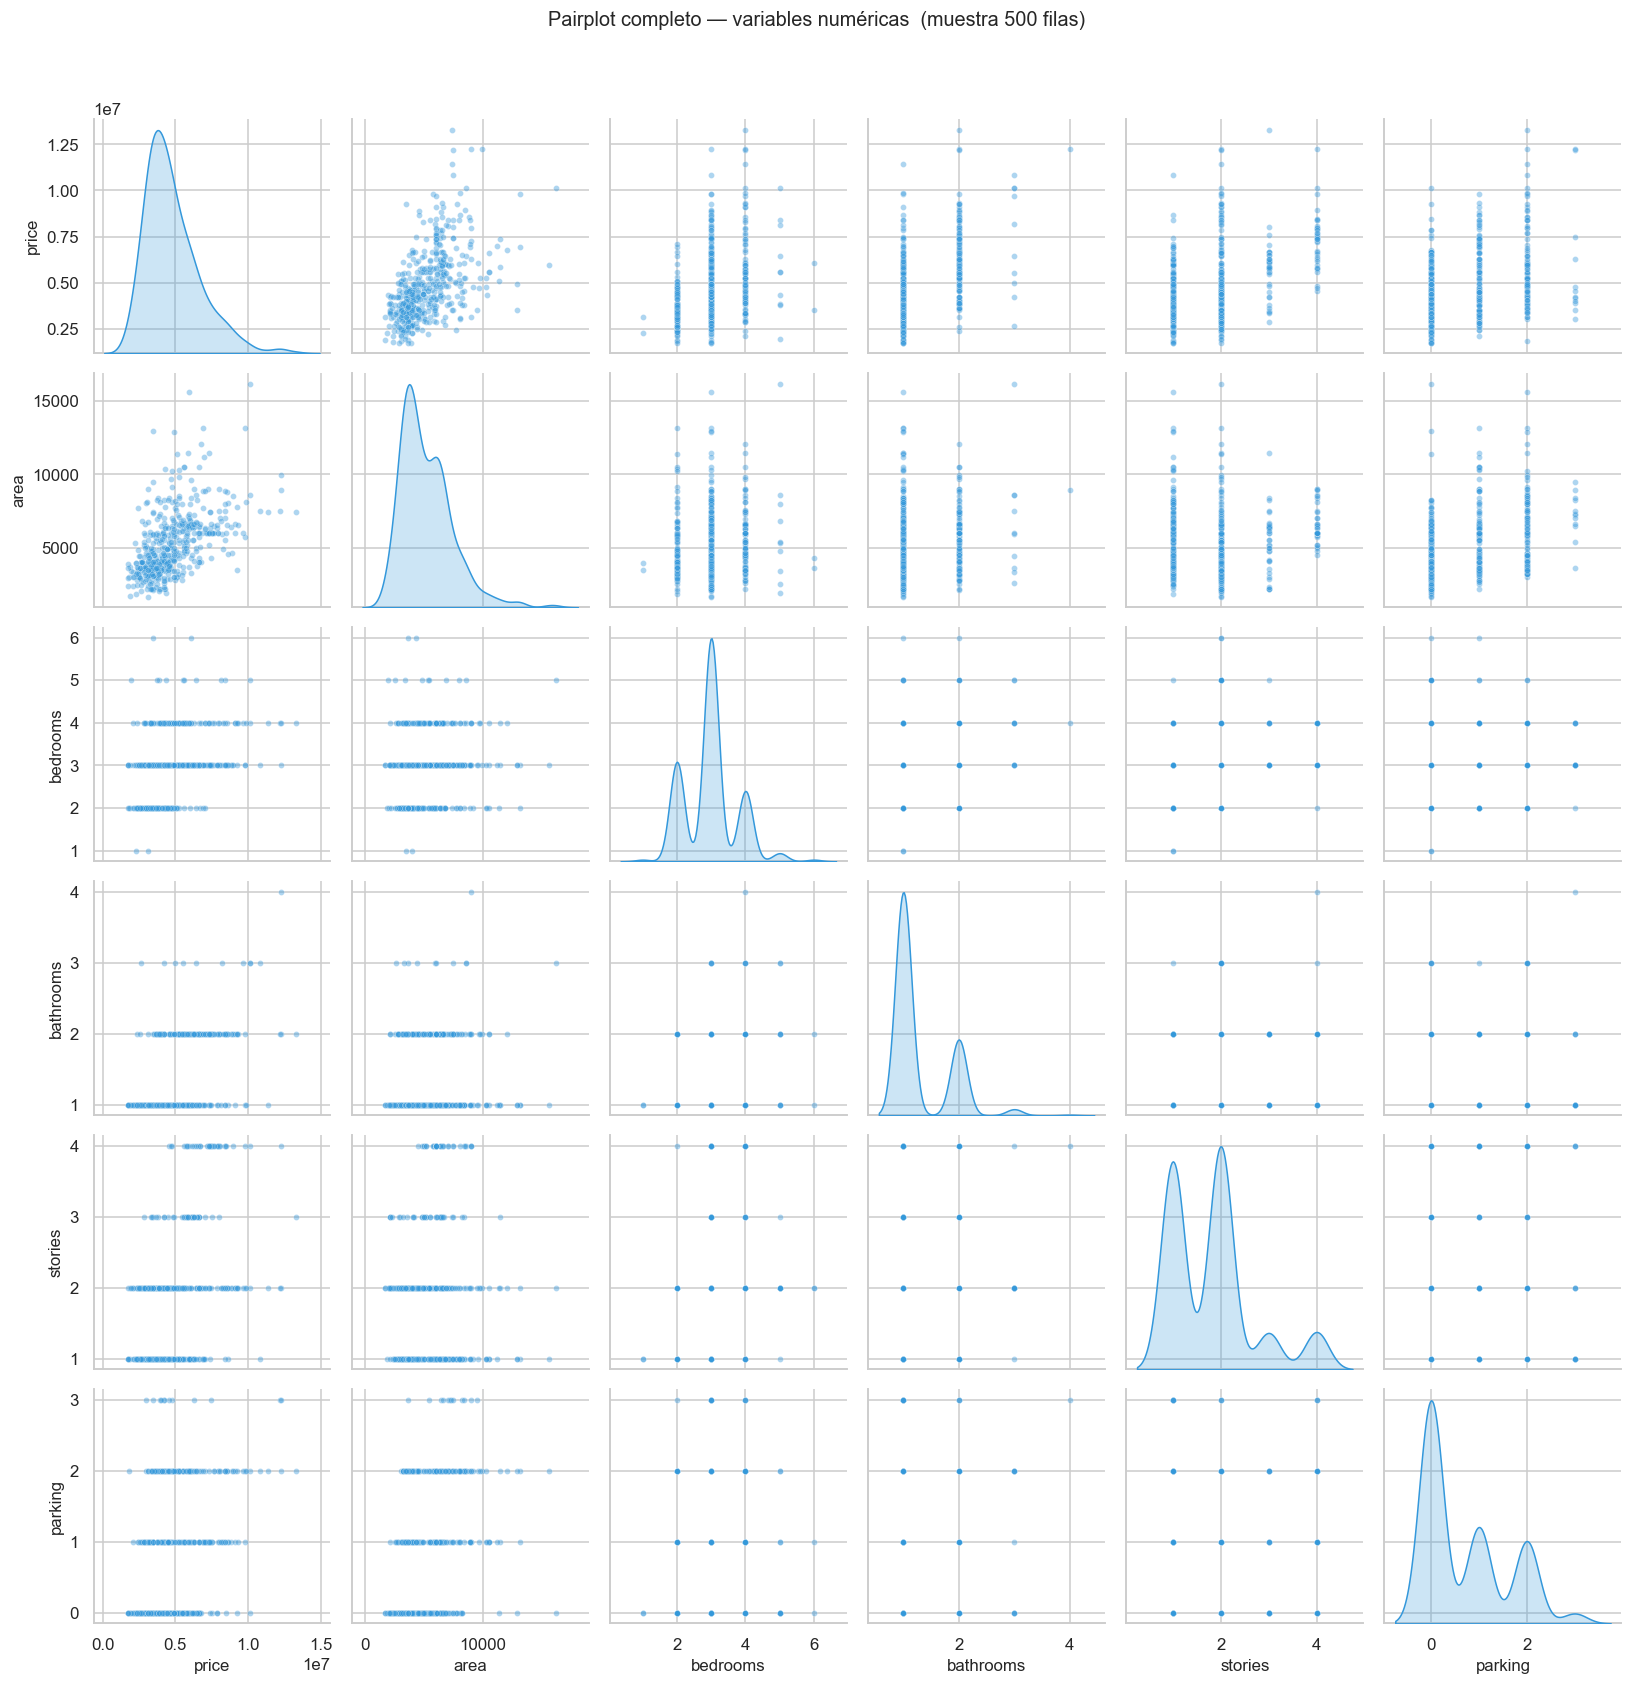


🔍 Variables con |corr. con price| ≥ 0.35: ['area', 'bathrooms', 'stories', 'parking', 'bedrooms']


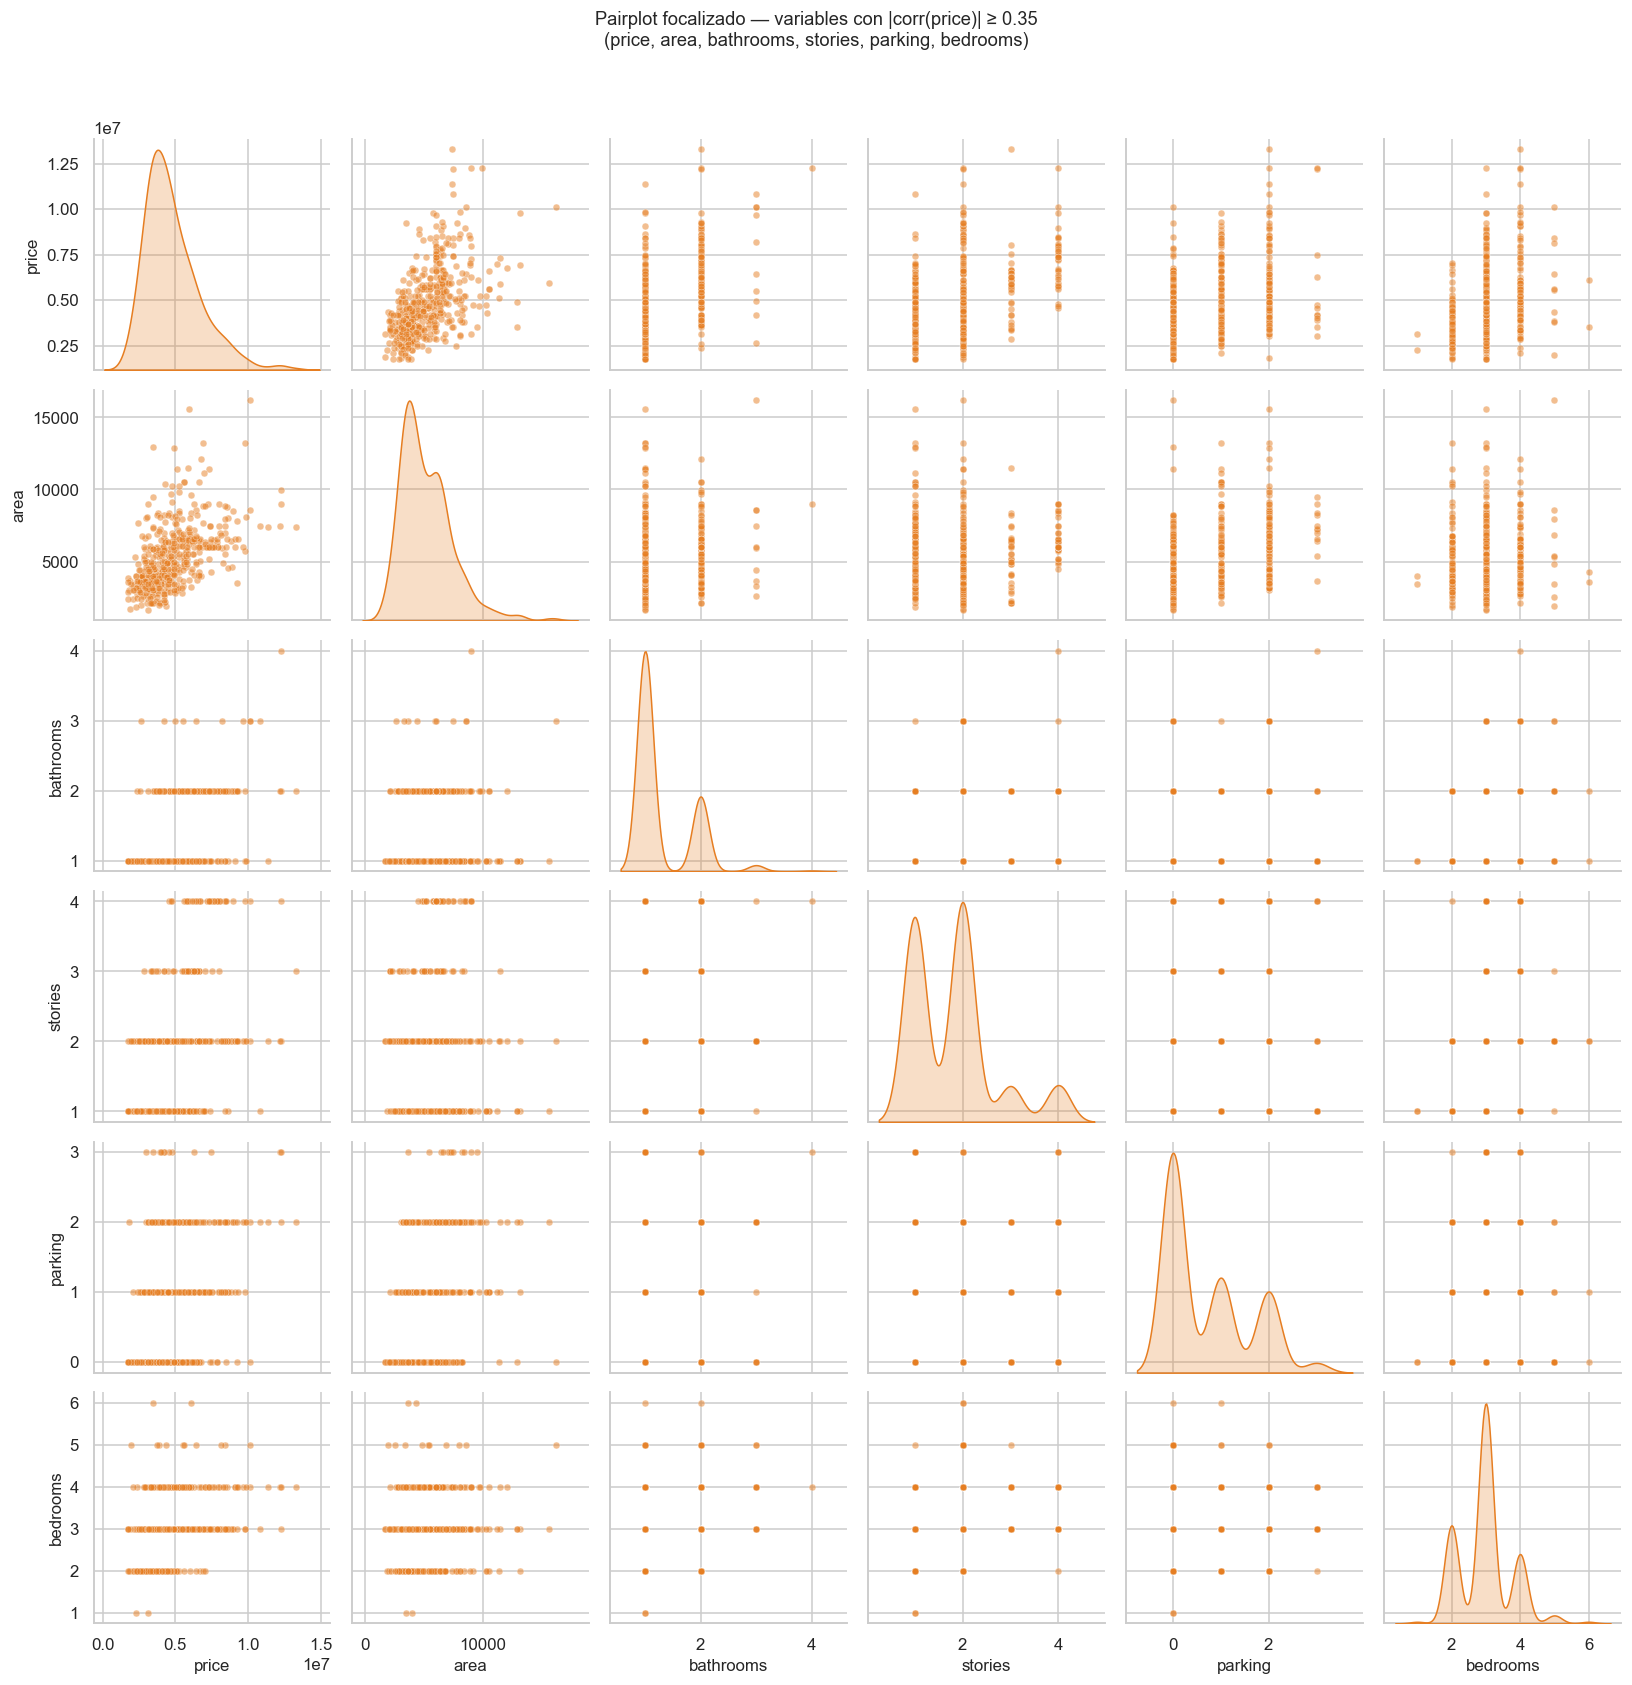


🔍 Interpretación del pairplot focalizado:
  · price vs area      : r = 0.54 — relación lineal positiva (fuerte)
  · price vs bathrooms : r = 0.52 — relación lineal positiva (fuerte)
  · price vs stories   : r = 0.42 — relación lineal positiva (moderada)
  · price vs parking   : r = 0.38 — relación lineal positiva (moderada)
  · price vs bedrooms  : r = 0.37 — relación lineal positiva (moderada)


In [31]:
cols_num = df.select_dtypes(include="number").columns.tolist()

# ── Parámetros de seguridad para rendimiento ──────────────────────────────────
MAX_PAIRPLOT_COLS = 8    # límite de columnas — pairplot de 8×8 ya es pesado
MAX_PAIRPLOT_ROWS = 500  # límite de filas    — samplear si el dataset crece
UMBRAL_CORR       = 0.35 # umbral de correlación para la versión focalizada

# ── Aplicar límites ───────────────────────────────────────────────────────────
cols_plot = cols_num[:MAX_PAIRPLOT_COLS]   # si hay más de MAX_PAIRPLOT_COLS, tomar las primeras
if len(df) > MAX_PAIRPLOT_ROWS:
    df_plot = df[cols_plot].sample(MAX_PAIRPLOT_ROWS, random_state=42)
    print(f"⚠️  Dataset > {MAX_PAIRPLOT_ROWS} filas → muestra de {MAX_PAIRPLOT_ROWS} filas para pairplot completo.")
else:
    df_plot = df[cols_plot]
    print(f"✅ {len(df)} filas — sin necesidad de muestreo (límite: {MAX_PAIRPLOT_ROWS}).")

if len(cols_num) > MAX_PAIRPLOT_COLS:
    print(f"⚠️  {len(cols_num)} columnas numéricas → pairplot limitado a las primeras {MAX_PAIRPLOT_COLS}: {cols_plot}")
else:
    print(f"✅ {len(cols_num)} columnas numéricas — todas incluidas en el pairplot completo.")

# ── Versión completa (con límites aplicados) ──────────────────────────────────
g_full = sns.pairplot(
    df_plot,
    diag_kind="kde",
    plot_kws=dict(alpha=0.4, s=15, color="#3498db"),
    diag_kws=dict(color="#3498db", fill=True),
)
g_full.figure.suptitle(
    f"Pairplot completo — variables numéricas"
    f"{'  (muestra ' + str(MAX_PAIRPLOT_ROWS) + ' filas)' if len(df) > MAX_PAIRPLOT_ROWS else ''}",
    y=1.02, fontsize=13
)
plt.tight_layout()
plt.show()

# ── Versión focalizada: variables más correladas con price ────────────────────
corr_previa = df[cols_num].corr()
cols_relevantes = (
    corr_previa["price"]
    .drop("price")
    .abs()
    .pipe(lambda s: s[s >= UMBRAL_CORR])
    .sort_values(ascending=False)
    .index
    .tolist()
)
cols_foco = ["price"] + cols_relevantes

print(f"\n🔍 Variables con |corr. con price| ≥ {UMBRAL_CORR}: {cols_relevantes}")

df_foco = df[cols_foco].sample(min(MAX_PAIRPLOT_ROWS, len(df)), random_state=42) if len(df) > MAX_PAIRPLOT_ROWS else df[cols_foco]

g_foco = sns.pairplot(
    df_foco,
    diag_kind="kde",
    plot_kws=dict(alpha=0.5, s=20, color="#e67e22"),
    diag_kws=dict(color="#e67e22", fill=True),
)
g_foco.figure.suptitle(
    f"Pairplot focalizado — variables con |corr(price)| ≥ {UMBRAL_CORR}\n"
    f"({', '.join(cols_foco)})",
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.show()

print("\n🔍 Interpretación del pairplot focalizado:")
for col in cols_relevantes:
    r = corr_previa.loc["price", col]
    direcc = "positiva" if r > 0 else "negativa"
    print(f"  · price vs {col:10s}: r = {r:.2f} — relación lineal {direcc} {'(fuerte)' if abs(r)>=0.5 else '(moderada)'}")


### 2.4 Mapa de calor de correlaciones

Se muestran dos versiones del mapa de calor:

- **Versión estándar**: orden original de columnas — vista global de la matriz completa.
- **Versión ordenada por correlación con `price`**: las variables se reordenan de mayor a menor `|r|` con `price`, facilitando la lectura de las relaciones más relevantes para el modelo.


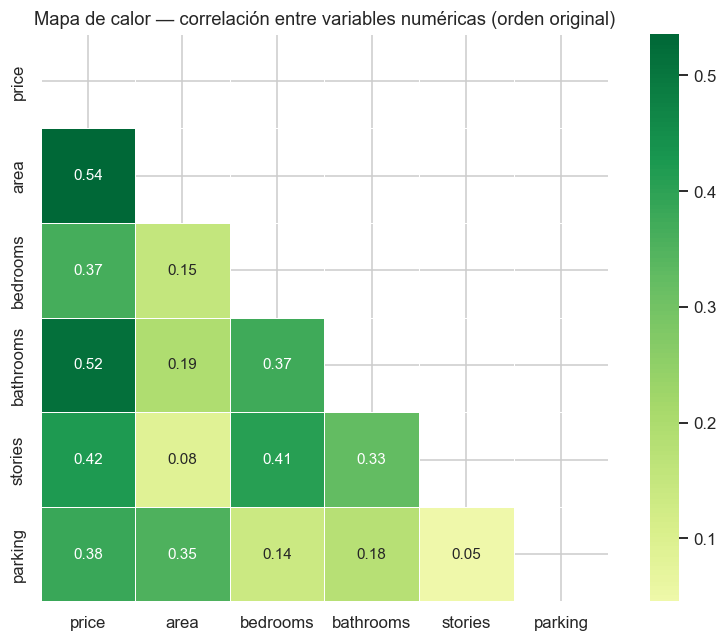

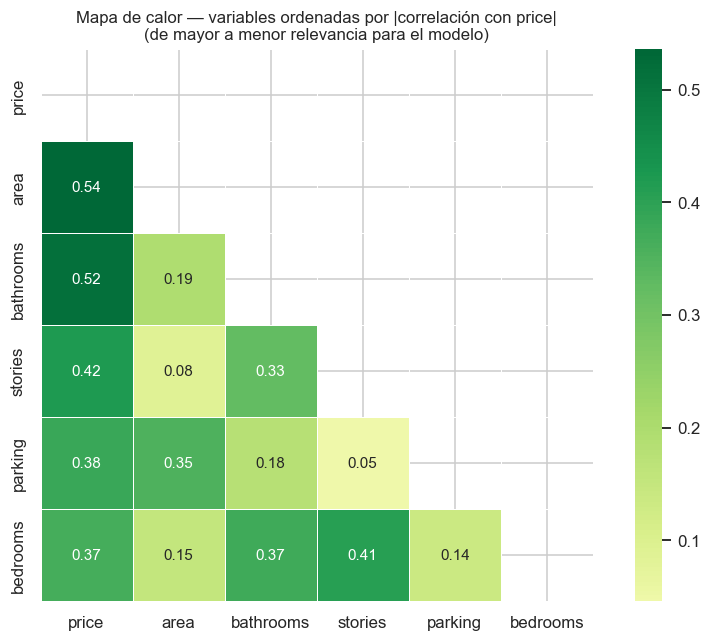


🔍 Correlación de cada variable con price (orden descendente):
area         0.536
bathrooms    0.518
stories      0.421
parking      0.384
bedrooms     0.366

📊 Interpretación del heatmap:
  · 'area' es el predictor numérico más correlado con price (r=0.54).

  · area        : |r| = 0.54 → correlación alta
  · bathrooms   : |r| = 0.52 → correlación alta
  · stories     : |r| = 0.42 → correlación moderada
  · parking     : |r| = 0.38 → correlación moderada
  · bedrooms    : |r| = 0.37 → correlación moderada

  ✅ No se detectan correlaciones inter-predictores > 0.5.


In [32]:
corr = df[cols_num].corr()

# ── Versión estándar ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.5,
    square=True, ax=ax, annot_kws={"size": 10}
)
ax.set_title("Mapa de calor — correlación entre variables numéricas (orden original)", fontsize=12)
plt.tight_layout()
plt.show()

# ── Versión ordenada por correlación con price ────────────────────────────────
# Reordenar columnas/filas: price primero, luego el resto de mayor a menor |r|
corr_price_order = corr["price"].drop("price").abs().sort_values(ascending=False)
ordered_cols      = ["price"] + corr_price_order.index.tolist()
corr_ordered      = corr.loc[ordered_cols, ordered_cols]
mask_ordered      = np.triu(np.ones_like(corr_ordered, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_ordered, mask=mask_ordered, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.5,
    square=True, ax=ax, annot_kws={"size": 10}
)
ax.set_title(
    "Mapa de calor — variables ordenadas por |correlación con price|\n"
    "(de mayor a menor relevancia para el modelo)",
    fontsize=11
)
plt.tight_layout()
plt.show()

# ── Ranking textual ───────────────────────────────────────────────────────────
corr_price = corr["price"].drop("price").abs().sort_values(ascending=False)
print("\n🔍 Correlación de cada variable con price (orden descendente):")
print(corr_price.round(3).to_string())

print("\n📊 Interpretación del heatmap:")
top_var = corr_price.index[0]
top_val = corr_price.iloc[0]
print(f"  · '{top_var}' es el predictor numérico más correlado con price (r={top_val:.2f}).")
print()
for var in corr_price.index:
    val = corr_price[var]
    nivel = "alta" if val >= 0.5 else ("moderada" if val >= 0.3 else "débil")
    print(f"  · {var:12s}: |r| = {val:.2f} → correlación {nivel}")
print()
# Multicolinealidad entre predictores
inter_pairs = []
for i, c1 in enumerate(cols_num):
    for c2 in cols_num[i+1:]:
        if c1 == "price" or c2 == "price": continue
        v = abs(corr.loc[c1, c2])
        if v > 0.5:
            inter_pairs.append((c1, c2, v))
if inter_pairs:
    print("  ⚠️ Pares con correlación inter-variable > 0.5 (posible multicolinealidad):")
    for c1, c2, v in sorted(inter_pairs, key=lambda x: -x[2]):
        print(f"     {c1} ↔ {c2}: r = {v:.2f}")
else:
    print("  ✅ No se detectan correlaciones inter-predictores > 0.5.")


---
## 3. Preprocesamiento de Datos

### 3.1 Comprobación de tipos y conversión a `category` antes del OHE

Antes de aplicar One-Hot Encoding se audita el tipo de dato de cada columna candidata:

- Las columnas que el dataset carga como `object` (cadena genérica) se convierten explícitamente a `category`.
- Se verifica que las columnas binarias sólo contienen los valores esperados (`yes` / `no`).
- Se detectan y reportan columnas numéricas que podrían haberse cargado incorrectamente como texto.

Esta comprobación hace el pipeline **robusto ante cambios en el dataset** (nuevas versiones del CSV, fuentes externas, cambios de codificación) y evita que `pd.get_dummies` procese silenciosamente columnas no previstas.


In [33]:
# ── Definición de columnas esperadas y sus tipos ─────────────────────────────
COLS_BINARIAS     = ["mainroad", "guestroom", "basement",
                     "hotwaterheating", "airconditioning", "prefarea"]
COLS_NOMINALES    = ["furnishingstatus"]
COLS_CATEGORICAS  = COLS_BINARIAS + COLS_NOMINALES
VALS_BINARIOS     = {"yes", "no"}

COLS_NUMERICAS_ESPERADAS = ["price", "area", "bedrooms",
                             "bathrooms", "stories", "parking"]

print("🔍 Auditoría de tipos antes del OHE\n")
print(f"  {'Columna':<22} {'dtype actual':>14}  {'dtype esperado':>16}  Estado")
print("  " + "─"*72)

issues = []   # acumula problemas encontrados

for col in COLS_CATEGORICAS:
    dtype_actual = str(df[col].dtype)

    # ── ¿Existe la columna? ────────────────────────────────────────────────────
    if col not in df.columns:
        issues.append(f"COLUMNA AUSENTE: '{col}' no existe en el DataFrame.")
        print(f"  {col:<22} {'—':>14}  {'category':>16}  ❌ ausente")
        continue

    # ── ¿Es numérica cuando debería ser categórica? ───────────────────────────
    if pd.api.types.is_numeric_dtype(df[col]):
        issues.append(
            f"TIPO INCORRECTO: '{col}' tiene dtype numérico ({dtype_actual}) "
            "pero se esperaba categórica."
        )
        print(f"  {col:<22} {dtype_actual:>14}  {'category':>16}  ⚠️  numérica inesperada")
        continue

    # ── Verificar valores permitidos en binarias ──────────────────────────────
    if col in COLS_BINARIAS:
        vals_unicos = set(df[col].str.strip().unique())
        inesperados = vals_unicos - VALS_BINARIOS
        if inesperados:
            issues.append(
                f"VALORES INESPERADOS en '{col}': {inesperados} "
                f"(permitidos: {VALS_BINARIOS})."
            )
            print(f"  {col:<22} {dtype_actual:>14}  {'category':>16}  ⚠️  valores extra: {inesperados}")
        else:
            print(f"  {col:<22} {dtype_actual:>14}  {'category':>16}  ✅")
    else:
        print(f"  {col:<22} {dtype_actual:>14}  {'category':>16}  ✅")

# ── Columnas numéricas: detectar si llegaron como object/string ───────────────
print()
for col in COLS_NUMERICAS_ESPERADAS:
    if col not in df.columns:
        issues.append(f"COLUMNA AUSENTE: '{col}' no existe en el DataFrame.")
        continue
    if not pd.api.types.is_numeric_dtype(df[col]):
        issues.append(
            f"TIPO INCORRECTO: '{col}' tiene dtype {df[col].dtype} "
            "pero se esperaba numérica."
        )
        print(f"  {col:<22} {str(df[col].dtype):>14}  {'numeric':>16}  ⚠️  debería ser numérica")

# ── Resumen ───────────────────────────────────────────────────────────────────
print()
if issues:
    print(f"⚠️  Se encontraron {len(issues)} problema(s):")
    for issue in issues:
        print(f"   · {issue}")
    raise ValueError(
        "Pipeline detenido: corrija los problemas de tipo antes de continuar.\n"
        + "\n".join(f"  · {i}" for i in issues)
    )
else:
    print("✅ Auditoría superada — todos los tipos son los esperados.")


🔍 Auditoría de tipos antes del OHE

  Columna                  dtype actual    dtype esperado  Estado
  ────────────────────────────────────────────────────────────────────────
  mainroad                          str          category  ✅
  guestroom                         str          category  ✅
  basement                          str          category  ✅
  hotwaterheating                   str          category  ✅
  airconditioning                   str          category  ✅
  prefarea                          str          category  ✅
  furnishingstatus                  str          category  ✅


✅ Auditoría superada — todos los tipos son los esperados.


In [34]:
# ── Conversión explícita a dtype 'category' ──────────────────────────────────
# pd.get_dummies reconoce automáticamente las columnas de tipo 'category'
# cuando no se especifica el parámetro columns=, lo que hace el pipeline
# más declarativo y menos propenso a codificar columnas no previstas.
# Aunque aquí pasamos columns= explícitamente, castear a 'category' sirve
# como contrato de datos: cualquier read_csv futuro que cargue una columna
# esperada como numérica o bool fallará en la auditoría anterior.

df_typed = df.copy()   # nunca mutar el DataFrame original

for col in COLS_CATEGORICAS:
    df_typed[col] = df_typed[col].str.strip().astype("category")

print("✅ Columnas categóricas convertidas a dtype 'category':\n")
for col in COLS_CATEGORICAS:
    cats = df_typed[col].cat.categories.tolist()
    print(f"  · {col:<22}  dtype={df_typed[col].dtype}  "
          f"categorías={cats}  "
          f"(ordered={df_typed[col].cat.ordered})")

print()
print(f"  ℹ️  'ordered=False' es correcto para variables nominales.")
print(f"  ℹ️  Si una variable fuese ordinal (ej. furnishingstatus low→mid→high),")
print(f"       podría definirse con CategoricalDtype(ordered=True) para reflejar")
print(f"       ese orden, aunque OHE con drop_first=True lo ignoraría igualmente.")


✅ Columnas categóricas convertidas a dtype 'category':

  · mainroad                dtype=category  categorías=['no', 'yes']  (ordered=False)
  · guestroom               dtype=category  categorías=['no', 'yes']  (ordered=False)
  · basement                dtype=category  categorías=['no', 'yes']  (ordered=False)
  · hotwaterheating         dtype=category  categorías=['no', 'yes']  (ordered=False)
  · airconditioning         dtype=category  categorías=['no', 'yes']  (ordered=False)
  · prefarea                dtype=category  categorías=['no', 'yes']  (ordered=False)
  · furnishingstatus        dtype=category  categorías=['furnished', 'semi-furnished', 'unfurnished']  (ordered=False)

  ℹ️  'ordered=False' es correcto para variables nominales.
  ℹ️  Si una variable fuese ordinal (ej. furnishingstatus low→mid→high),
       podría definirse con CategoricalDtype(ordered=True) para reflejar
       ese orden, aunque OHE con drop_first=True lo ignoraría igualmente.


In [35]:
# ── One-Hot Encoding sobre df_typed (dtype 'category' ya asignado) ──────────
df_encoded = pd.get_dummies(
    df_typed,
    columns=COLS_CATEGORICAS,
    drop_first=True,      # elimina una categoría por variable → evita trampa de variable dummy
    dtype=int
)

print(f"📐 Shape original:   {df.shape}")
print(f"📐 Shape codificado: {df_encoded.shape}")
print(f"\n📋 Columnas tras OHE:")
for col in df_encoded.columns:
    print(f"  · {col}")


📐 Shape original:   (545, 13)
📐 Shape codificado: (545, 14)

📋 Columnas tras OHE:
  · price
  · area
  · bedrooms
  · bathrooms
  · stories
  · parking
  · mainroad_yes
  · guestroom_yes
  · basement_yes
  · hotwaterheating_yes
  · airconditioning_yes
  · prefarea_yes
  · furnishingstatus_semi-furnished
  · furnishingstatus_unfurnished


### 3.2 Separación de features y variable objetivo


In [36]:
X = df_encoded.drop(columns=["price"])
y = df_encoded["price"]

print(f"✅ Features (X):          {X.shape}")
print(f"✅ Variable objetivo (y): {y.shape}")
print(f"\n📋 Features usadas:")
for col in X.columns:
    print(f"  · {col}")


✅ Features (X):          (545, 13)
✅ Variable objetivo (y): (545,)

📋 Features usadas:
  · area
  · bedrooms
  · bathrooms
  · stories
  · parking
  · mainroad_yes
  · guestroom_yes
  · basement_yes
  · hotwaterheating_yes
  · airconditioning_yes
  · prefarea_yes
  · furnishingstatus_semi-furnished
  · furnishingstatus_unfurnished


### 3.3 Estandarización de variables numéricas

Aplicamos `StandardScaler` exclusivamente a las **5 columnas numéricas continuas / de rango amplio**:
`area`, `bedrooms`, `bathrooms`, `stories` y `parking`.

**¿Por qué solo estas y no todas las columnas?**

| Columna | Tipo | ¿Se escala? | Justificación |
|---------|------|:-----------:|---------------|
| `area` | Numérica continua (rango ~1650–16200) | ✅ Sí | Rango muy amplio — sin escalar dominaría la distancia y los gradientes |
| `bedrooms` | Discreta (1–6) | ✅ Sí | Misma unidad semántica que bathrooms/stories — escalar iguala su contribución |
| `bathrooms` | Discreta (1–4) | ✅ Sí | ídem |
| `stories` | Discreta (1–4) | ✅ Sí | ídem |
| `parking` | Discreta (0–3) | ✅ Sí | ídem |
| `mainroad_yes`, `guestroom_yes`… | Binaria OHE (0/1) | ❌ No | Ya están en escala [0,1]; escalarlas distorsionaría su interpretación booleana |
| `furnishingstatus_*` | Binaria OHE (0/1) | ❌ No | ídem — columnas dummy no deben estandarizarse |

> ⚠️ **Importante:** el scaler se ajusta (`fit`) **exclusivamente** sobre el conjunto de entrenamiento para evitar *data leakage*. El mismo objeto `scaler` (con los parámetros aprendidos en train) se aplica sin re-ajustar al test set.


In [37]:
# Variables a estandarizar (numéricas continuas / discretas con rango amplio)
cols_escalar = ["area", "bedrooms", "bathrooms", "stories", "parking"]

# División train/test ANTES de escalar
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Copias explícitas para evitar SettingWithCopyWarning ─────────────────────
# train_test_split puede devolver vistas del DataFrame original.
# Operar sobre vistas con asignación de columnas genera SettingWithCopyWarning
# en pandas < 3.0 y puede producir resultados inesperados.
# .copy() garantiza que X_train y X_test son DataFrames independientes.
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

scaler = StandardScaler()
X_train[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])  # fit+transform en train
X_test[cols_escalar]  = scaler.transform(X_test[cols_escalar])       # solo transform en test

print(f"✅ Copias explícitas creadas → sin riesgo de SettingWithCopyWarning")
print(f"✅ Escalado aplicado a: {cols_escalar}")
print(f"\n📐 Train set: {X_train.shape[0]} filas  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"📐 Test  set: {X_test.shape[0]}  filas  ({X_test.shape[0]/len(X)*100:.0f}%)")


✅ Copias explícitas creadas → sin riesgo de SettingWithCopyWarning
✅ Escalado aplicado a: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

📐 Train set: 436 filas  (80%)
📐 Test  set: 109  filas  (20%)


---
## 4. División del Dataset en Entrenamiento y Prueba

El dataset se ha dividido en la sección anterior aplicando el orden correcto (**split → escalar**). Aquí verificamos las proporciones y la distribución de `price` en ambos conjuntos.


In [38]:
print("📊 Resumen de la división:")
print(f"  Total de registros:       {len(X)}")
print(f"  Entrenamiento (train 80%): {len(X_train)}")
print(f"  Prueba (test  20%):        {len(X_test)}")
print(f"  random_state=42 → reproducible")

print(f"\n📈 Estadísticas de 'price' en cada conjunto:")
resumen = pd.DataFrame({
    "Train": y_train.describe(),
    "Test":  y_test.describe(),
}).round(0)
print(resumen.to_string())


📊 Resumen de la división:
  Total de registros:       545
  Entrenamiento (train 80%): 436
  Prueba (test  20%):        109
  random_state=42 → reproducible

📈 Estadísticas de 'price' en cada conjunto:
            Train        Test
count       436.0       109.0
mean    4706527.0   5007537.0
std     1757976.0   2258622.0
min     1750000.0   1750000.0
25%     3498250.0   3290000.0
50%     4291000.0   4550000.0
75%     5600000.0   6510000.0
max    12250000.0  13300000.0


---
## 5. Creación y Entrenamiento del Modelo de Regresión Lineal

### 5.1 Entrenamiento


In [39]:
# ── Nota sobre n_jobs en LinearRegression ────────────────────────────────────
# LinearRegression resuelve el sistema de ecuaciones normales mediante
# descomposición SVD (scipy.linalg.lstsq) en una única llamada LAPACK.
# No expone un parámetro n_jobs porque el cómputo no se puede paralelizar
# por pliegues o estimadores: la paralelización sí tiene efecto en
# cross_val_score y en Ridge/Lasso (ver sección 6.3 y 6.4).
#
# Extensiones opcionales (fuera del enunciado):
#   · SGDRegressor: solver iterativo escalable a datasets de millones de filas;
#     admite n_jobs y mini-batches (sklearn.linear_model.SGDRegressor).
#   · HuberRegressor: regresor robusto frente a outliers extremos — minimiza
#     la función de pérdida de Huber en lugar del MSE; útil cuando price
#     presenta outliers que no conviene eliminar (sklearn.linear_model.HuberRegressor).
#   Ambos son extensiones válidas al modelo base pero no requeridas por el enunciado.
modelo = LinearRegression()  # implementación por defecto (SVD via LAPACK/BLAS)
modelo.fit(X_train, y_train)

print("✅ Modelo entrenado correctamente.")
print(f"\n📋 Intercepto (β₀): {modelo.intercept_:,.2f}")
print()
print("ℹ️  LinearRegression usa SVD vía LAPACK — sin parámetro n_jobs.")
print("   Extensiones opcionales: SGDRegressor (escalable) · HuberRegressor (robusto a outliers).")


✅ Modelo entrenado correctamente.

📋 Intercepto (β₀): 3,969,403.56

ℹ️  LinearRegression usa SVD vía LAPACK — sin parámetro n_jobs.
   Extensiones opcionales: SGDRegressor (escalable) · HuberRegressor (robusto a outliers).


### 5.2 Coeficientes del modelo — escalados y en unidades originales

Mostramos dos versiones de los coeficientes:

- **`Coef_escalado`**: el coeficiente tal como lo aprende el modelo (sobre features estandarizadas). Permite comparar el *impacto relativo* de cada variable numérica directamente.
- **`Coef_original`**: el coeficiente reescalado a **unidades originales** dividiendo por la desviación estándar del train set. Responde a: *¿cuánto cambia `price` si esta variable sube 1 unidad real?*

Para las columnas binarias OHE (0/1), el coeficiente ya está en su escala natural — no requiere reescalado.


📋 Tabla A — Coeficientes ordenados por Coef_escalado (impacto relativo entre vars estandarizadas):

                        Feature               Tipo  Coef_escalado  Coef_original
            airconditioning_yes        Binaria OHE  791426.735843  791426.735843
            hotwaterheating_yes        Binaria OHE  684649.885339  684649.885339
                   prefarea_yes        Binaria OHE  629890.565313  629890.565313
                      bathrooms Numérica (estand.)  521879.027748  521280.199062
                           area Numérica (estand.)  519552.416340  518956.257318
                   basement_yes        Binaria OHE  390251.176181  390251.176181
                   mainroad_yes        Binaria OHE  367919.947680  367919.947680
                        stories Numérica (estand.)  349251.438906  348850.691282
                  guestroom_yes        Binaria OHE  231610.037176  231610.037176
                        parking Numérica (estand.)  192005.953667  191785.636953
         

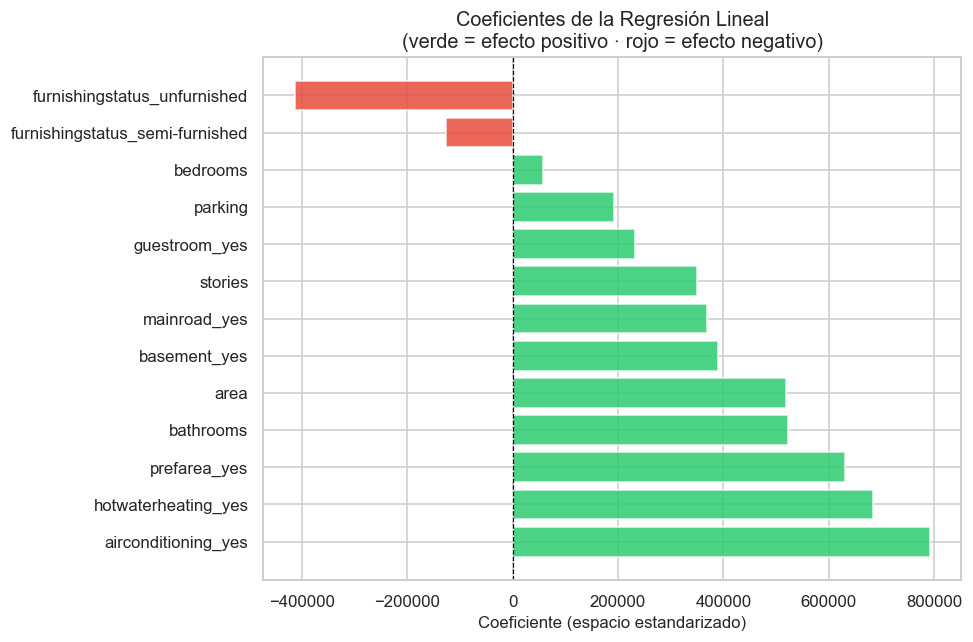


🔍 Interpretación en unidades originales (ordenada por |efecto|):
  Intercepto (β₀): 3,969,403.56

  · airconditioning_yes       → presencia (1)   cambia price en     +791,427
  · hotwaterheating_yes       → presencia (1)   cambia price en     +684,650
  · prefarea_yes              → presencia (1)   cambia price en     +629,891
  · bathrooms                 → +1 unidad real  cambia price en     +521,280
  · area                      → +1 unidad real  cambia price en     +518,956
  · furnishingstatus_unfurnished → presencia (1)   cambia price en     -413,645
  · basement_yes              → presencia (1)   cambia price en     +390,251
  · mainroad_yes              → presencia (1)   cambia price en     +367,920
  · stories                   → +1 unidad real  cambia price en     +348,851
  · guestroom_yes             → presencia (1)   cambia price en     +231,610
  · parking                   → +1 unidad real  cambia price en     +191,786
  · furnishingstatus_semi-furnished → presencia (1)

In [40]:
# ── Construir tabla de coeficientes ──────────────────────────────────────────
stds_train = {col: X_train[col].std() for col in cols_escalar}

coef_rows = []
for feat, coef in zip(X_train.columns, modelo.coef_):
    if feat in cols_escalar:
        std = stds_train[feat]
        coef_original = coef / std if std != 0 else np.nan
        tipo = "Numérica (estand.)"
    else:
        coef_original = coef
        tipo = "Binaria OHE"
    coef_rows.append({"Feature": feat, "Tipo": tipo,
                      "Coef_escalado": coef, "Coef_original": coef_original})

coef_df = (pd.DataFrame(coef_rows)
             .sort_values("Coef_escalado", ascending=False)
             .reset_index(drop=True))

print("📋 Tabla A — Coeficientes ordenados por Coef_escalado (impacto relativo entre vars estandarizadas):\n")
print(coef_df.to_string(index=False))

# ── Tabla B: ordenada por |Coef_original| — efecto marginal real ──────────────
coef_df_orig = (coef_df.assign(Abs_orig=coef_df["Coef_original"].abs())
                        .sort_values("Abs_orig", ascending=False)
                        .drop(columns="Abs_orig")
                        .reset_index(drop=True))

print("\n📋 Tabla B — Coeficientes ordenados por |Coef_original| (efecto marginal en unidades reales):\n")
print(coef_df_orig[["Feature","Tipo","Coef_original","Coef_escalado"]].to_string(index=False))
print()
print("  ℹ️  Tabla B responde: '¿qué variable tiene el mayor efecto marginal sobre price")
print("      medido en unidades originales?' — independientemente de la escala de medición.")

# ── Gráfico: coeficientes escalados ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
colores = ["#2ecc71" if v > 0 else "#e74c3c" for v in coef_df["Coef_escalado"]]
ax.barh(coef_df["Feature"], coef_df["Coef_escalado"],
        color=colores, edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Coeficiente (espacio estandarizado)")
ax.set_title("Coeficientes de la Regresión Lineal\n"
             "(verde = efecto positivo · rojo = efecto negativo)")
plt.tight_layout()
plt.show()

# ── Interpretación automática en unidades originales ─────────────────────────
print("\n🔍 Interpretación en unidades originales (ordenada por |efecto|):")
print(f"  Intercepto (β₀): {modelo.intercept_:,.2f}\n")
for _, row in coef_df_orig.iterrows():
    coef_o = row["Coef_original"]
    if row["Tipo"] == "Numérica (estand.)":
        print(f"  · {row['Feature']:25s} → +1 unidad real  cambia price en {coef_o:>+12,.0f}")
    else:
        print(f"  · {row['Feature']:25s} → presencia (1)   cambia price en {coef_o:>+12,.0f}")


---
## 6. Evaluación del Modelo

### 6.1 Métricas de rendimiento


In [41]:
y_pred = modelo.predict(X_test)

n_test = len(y_test)
p      = X_test.shape[1]   # número de predictores

mse   = mean_squared_error(y_test, y_pred)
mae   = mean_absolute_error(y_test, y_pred)
r2    = r2_score(y_test, y_pred)
rmse  = np.sqrt(mse)

# R² ajustado: penaliza la adición de predictores que no aportan varianza explicada
# Fórmula: 1 - (1-R²) * (n-1) / (n-p-1)
r2_adj = 1 - (1 - r2) * (n_test - 1) / (n_test - p - 1)

print("📊 Métricas de evaluación en el conjunto de TEST:\n")
print(f"  {'MSE  (Error Cuadrático Medio):':50s} {mse:>15,.2f}")
print(f"  {'RMSE (Raíz del Error Cuadrático Medio):':50s} {rmse:>15,.2f}")
print(f"  {'MAE  (Error Absoluto Medio):':50s} {mae:>15,.2f}")
print(f"  {'R²   (Coeficiente de Determinación):':50s} {r2:>15.4f}")
print(f"  {'R² ajustado (penaliza nº de predictores):':50s} {r2_adj:>15.4f}")

print(f"\n  💡 El modelo explica el {r2*100:.1f}% de la varianza de price.")
print(f"  💡 R² ajustado = {r2_adj:.4f} — penaliza los {p} predictores del modelo.")
if abs(r2 - r2_adj) < 0.02:
    print(f"  ✅ R² y R² ajustado son muy próximos → los {p} predictores están justificados.")
else:
    print(f"  ⚠️ Diferencia R² vs R²_adj = {abs(r2-r2_adj):.4f} → algunos predictores podrían ser redundantes.")
print(f"  💡 El error medio por predicción es de ±{mae:,.0f} unidades.")


📊 Métricas de evaluación en el conjunto de TEST:

  MSE  (Error Cuadrático Medio):                     1,754,318,687,330.67
  RMSE (Raíz del Error Cuadrático Medio):               1,324,506.96
  MAE  (Error Absoluto Medio):                            970,043.40
  R²   (Coeficiente de Determinación):                        0.6529
  R² ajustado (penaliza nº de predictores):                   0.6054

  💡 El modelo explica el 65.3% de la varianza de price.
  💡 R² ajustado = 0.6054 — penaliza los 13 predictores del modelo.
  ⚠️ Diferencia R² vs R²_adj = 0.0475 → algunos predictores podrían ser redundantes.
  💡 El error medio por predicción es de ±970,043 unidades.


### 6.2 Rendimiento en train vs test — verificación de sobreajuste


In [42]:
y_pred_train = modelo.predict(X_train)

n_tr = len(y_train)
p    = X_train.shape[1]

r2_train     = r2_score(y_train, y_pred_train)
r2_test_     = r2_score(y_test,  y_pred)
r2_adj_train = 1 - (1 - r2_train) * (n_tr - 1) / (n_tr - p - 1)
r2_adj_test  = 1 - (1 - r2_test_) * (len(y_test) - 1) / (len(y_test) - p - 1)

print(f"  {'Métrica':<25} {'TRAIN':>10}  {'TEST':>10}  {'Diferencia':>12}")
print("  " + "─"*58)
print(f"  {'R²':<25} {r2_train:>10.4f}  {r2_test_:>10.4f}  {abs(r2_train-r2_test_):>12.4f}")
print(f"  {'R² ajustado':<25} {r2_adj_train:>10.4f}  {r2_adj_test:>10.4f}  {abs(r2_adj_train-r2_adj_test):>12.4f}")

print()
if abs(r2_train - r2_test_) < 0.05:
    print("  ✅ La diferencia de R² entre train y test es pequeña → no hay indicios de sobreajuste.")
else:
    print("  ⚠️ Diferencia notable entre train y test → posible sobreajuste.")

print()
print("  ℹ️  El R² ajustado descuenta la inflación artificial que producen predictores")
print(f"      no informativos. Con {p} predictores y {n_tr} muestras de train,")
print(f"      la penalización es de {(1-r2_train)*((n_tr-1)/(n_tr-p-1)-1):.4f} puntos sobre R².")


  Métrica                        TRAIN        TEST    Diferencia
  ──────────────────────────────────────────────────────────
  R²                            0.6859      0.6529        0.0330
  R² ajustado                   0.6763      0.6054        0.0708

  ✅ La diferencia de R² entre train y test es pequeña → no hay indicios de sobreajuste.

  ℹ️  El R² ajustado descuenta la inflación artificial que producen predictores
      no informativos. Con 13 predictores y 436 muestras de train,
      la penalización es de 0.0097 puntos sobre R².


### 6.3 Validación cruzada K-Fold (k=5)

Para robustecer la estimación del rendimiento más allá de un único split train/test, aplicamos **K-Fold cross-validation** con 5 pliegues sobre el conjunto de entrenamiento.

Esto produce 5 estimaciones independientes de R², MSE y MAE, cuya media y desviación estándar reflejan la **estabilidad real del modelo** frente a diferentes particiones de los datos.


In [43]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── Validación cruzada con LinearRegression ───────────────────────────────────
cv_r2  = cross_val_score(LinearRegression(), X_train, y_train,
                          cv=kf, scoring="r2", n_jobs=-1)
cv_mse = -cross_val_score(LinearRegression(), X_train, y_train,
                           cv=kf, scoring="neg_mean_squared_error", n_jobs=-1)
cv_mae = -cross_val_score(LinearRegression(), X_train, y_train,
                           cv=kf, scoring="neg_mean_absolute_error", n_jobs=-1)

print("📊 Validación cruzada K-Fold (k=5) — LinearRegression\n")
print(f"  {'Métrica':<10}  {'Fold 1':>10}  {'Fold 2':>10}  {'Fold 3':>10}  {'Fold 4':>10}  {'Fold 5':>10}  {'Media':>10}  {'Std':>8}")
print("  " + "─"*80)
for name, vals in [("R²", cv_r2), ("RMSE", np.sqrt(cv_mse)), ("MAE", cv_mae)]:
    vals_fmt = "  ".join(f"{v:>10.4f}" if name=="R²" else f"{v:>10,.0f}" for v in vals)
    media = np.mean(vals)
    std   = np.std(vals)
    fmt_m = f"{media:.4f}" if name=="R²" else f"{media:,.0f}"
    fmt_s = f"{std:.4f}"  if name=="R²" else f"{std:,.0f}"
    print(f"  {name:<10}  {vals_fmt}  {fmt_m:>10}  {fmt_s:>8}")

print()
print(f"  💡 R² medio CV:  {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"  💡 RMSE medio CV: {np.sqrt(cv_mse).mean():,.0f} ± {np.sqrt(cv_mse).std():,.0f}")

# Comparar CV vs test único
print(f"\n📐 Comparación CV (media) vs. split único:")
print(f"  R² test-único = {r2:.4f}   |   R² CV-medio = {cv_r2.mean():.4f}   |   Δ = {abs(r2 - cv_r2.mean()):.4f}")
if abs(r2 - cv_r2.mean()) < 0.03:
    print("  ✅ Ambas estimaciones son consistentes → el split único es representativo.")
else:
    print("  ⚠️ Diferencia notable → preferir la estimación CV como métrica de referencia.")


📊 Validación cruzada K-Fold (k=5) — LinearRegression

  Métrica         Fold 1      Fold 2      Fold 3      Fold 4      Fold 5       Media       Std
  ────────────────────────────────────────────────────────────────────────────────
  R²              0.6338      0.5955      0.7304      0.6577      0.6278      0.6490    0.0452
  RMSE         1,062,582   1,001,835   1,004,237   1,093,845     955,399   1,023,579    48,896
  MAE            795,581     704,819     752,003     756,147     727,495     747,209    30,424

  💡 R² medio CV:  0.6490 ± 0.0452
  💡 RMSE medio CV: 1,023,579 ± 48,896

📐 Comparación CV (media) vs. split único:
  R² test-único = 0.6529   |   R² CV-medio = 0.6490   |   Δ = 0.0039
  ✅ Ambas estimaciones son consistentes → el split único es representativo.


### 6.4 Comparación con modelos regularizados — Ridge y Lasso

Aunque el enunciado exige Regresión Lineal básica, incluimos Ridge (L2) y Lasso (L1) como referencia para cuantificar el efecto de la regularización sobre el rendimiento.

- **Ridge** penaliza la suma de cuadrados de los coeficientes → reduce su magnitud sin anularlos.
- **Lasso** penaliza la suma de valores absolutos → puede anular coeficientes (selección de variables implícita).

Se usa `n_jobs=-1` en `cross_val_score` para paralelizar los pliegues sobre todos los núcleos disponibles.


📊 Comparación de modelos en test set:

  Modelo                                     R²            RMSE             MAE
  ───────────────────────────────────────────────────────────────────────────
  LinearRegression                       0.6529       1,324,507         970,043
  Ridge (α=6.55)                         0.6479       1,334,137         976,945
  Lasso (α=4.0949)                       0.6529       1,324,512         970,046

  🔍 Lasso anuló 0 de 13 coeficientes → selección implícita de variables.


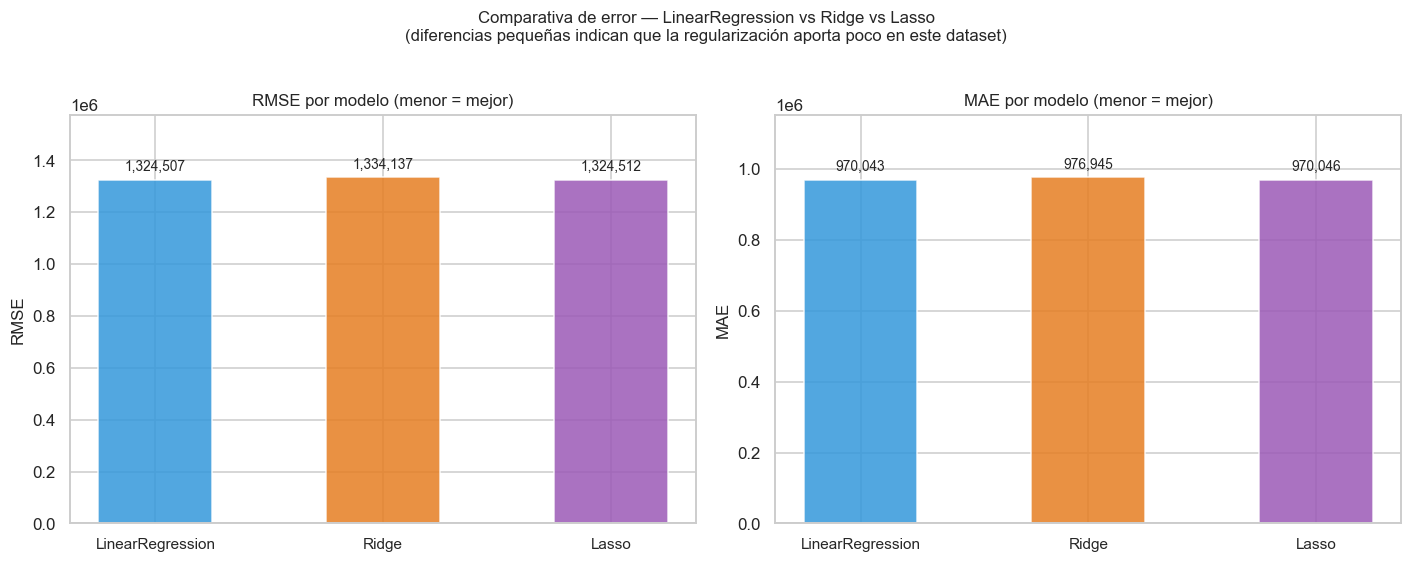


📊 Validación cruzada CV (k=5) con n_jobs=-1:

  LinearRegression                          R² CV = 0.6490 ± 0.0452
  Ridge (α=6.55)                            R² CV = 0.6506 ± 0.0428
  Lasso (α=4.0949)                          R² CV = 0.6490 ± 0.0452


In [44]:
from sklearn.linear_model import RidgeCV, LassoCV

# ── RidgeCV / LassoCV ────────────────────────────────────────────────────────
ridge = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=5)
ridge.fit(X_train, y_train)

lasso = LassoCV(alphas=np.logspace(-2, 6, 50), cv=5, max_iter=10000, n_jobs=-1)
lasso.fit(X_train, y_train)

nombres_modelos = [
    "LinearRegression",
    f"Ridge (α={ridge.alpha_:.2f})",
    f"Lasso (α={lasso.alpha_:.4f})",
]
modelos_lista = [modelo, ridge, lasso]

# ── Tabla de métricas ─────────────────────────────────────────────────────────
print("📊 Comparación de modelos en test set:\n")
print(f"  {'Modelo':<35}  {'R²':>8}  {'RMSE':>14}  {'MAE':>14}")
print("  " + "─"*75)

metricas = {}
for nombre, m in zip(nombres_modelos, modelos_lista):
    yp    = m.predict(X_test)
    r2_   = r2_score(y_test, yp)
    rmse_ = np.sqrt(mean_squared_error(y_test, yp))
    mae_  = mean_absolute_error(y_test, yp)
    metricas[nombre] = {"R2": r2_, "RMSE": rmse_, "MAE": mae_}
    print(f"  {nombre:<35}  {r2_:>8.4f}  {rmse_:>14,.0f}  {mae_:>14,.0f}")

n_zero = (np.abs(lasso.coef_) < 1e-6).sum()
print(f"\n  🔍 Lasso anuló {n_zero} de {len(lasso.coef_)} coeficientes → selección implícita de variables.")

# ── Gráfico comparativo MSE / MAE ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores_bar = ["#3498db", "#e67e22", "#9b59b6"]
x = np.arange(len(nombres_modelos))
w = 0.5

for ax, metrica, titulo in zip(
    axes,
    ["RMSE", "MAE"],
    ["RMSE por modelo (menor = mejor)", "MAE por modelo (menor = mejor)"]
):
    vals = [metricas[n][metrica] for n in nombres_modelos]
    bars = ax.bar(x, vals, color=colores_bar, width=w, edgecolor="white", alpha=0.85)
    ax.bar_label(bars, fmt=lambda v: f"{v:,.0f}", padding=4, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([n.split(" ")[0] for n in nombres_modelos], fontsize=10)
    ax.set_ylabel(metrica)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylim(0, max(vals) * 1.18)

fig.suptitle(
    "Comparativa de error — LinearRegression vs Ridge vs Lasso\n"
    "(diferencias pequeñas indican que la regularización aporta poco en este dataset)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

# ── CV paralelo para los 3 modelos ───────────────────────────────────────────
print("\n📊 Validación cruzada CV (k=5) con n_jobs=-1:\n")
for nombre, clf in [
    ("LinearRegression",      LinearRegression()),
    (f"Ridge (α={ridge.alpha_:.2f})", Ridge(alpha=ridge.alpha_)),
    (f"Lasso (α={lasso.alpha_:.4f})", Lasso(alpha=lasso.alpha_, max_iter=10000)),
]:
    scores = cross_val_score(clf, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    print(f"  {nombre:<40}  R² CV = {scores.mean():.4f} ± {scores.std():.4f}")


---
## 7. Visualización de Resultados

### 7.1 Valores reales vs. predichos


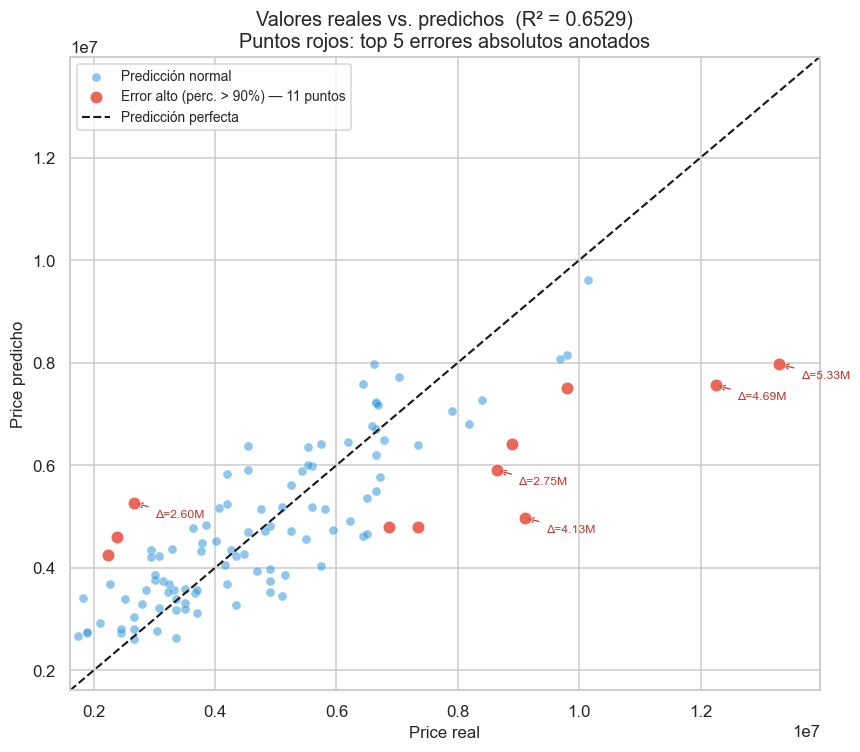


🔴 Los 5 mayores errores absolutos del modelo:
     Idx      Price real      Price pred       Error abs     Error %
  ─────────────────────────────────────────────────────────────────
       0      13,300,000       7,968,276       5,331,724       40.1%
       2      12,250,000       7,555,324       4,694,676       38.3%
      15       9,100,000       4,973,331       4,126,669       45.3%
      22       8,645,000       5,897,889       2,747,111       31.8%
     499       2,660,000       5,263,188       2,603,188       97.9%

🔍 Patrón observado: los mayores errores tienden a concentrarse en viviendas
   de precio elevado (cola derecha de la distribución), consistente con la
   heterocedasticidad leve detectada en la sección 7.3.


In [45]:
# ── Calcular residuos absolutos para colorear y anotar extremos ──────────────
abs_res   = np.abs(y_test - y_pred)
N_EXTREMOS = 5   # número de puntos más erróneos a destacar

# ── Fix: y_pred es array numpy (índices 0..n-1) pero y_test y abs_res son
# Series pandas con los índices originales del DataFrame (e.g. 499, 312…).
# idx_top contiene esos índices originales, por lo que y_pred[499] lanza
# IndexError porque el array solo tiene 109 posiciones.
# Solución: convertir y_pred a Series alineada con y_test antes de indexar.
y_pred_s = pd.Series(y_pred, index=y_test.index)

# Umbral: percentil 90 de errores absolutos
umbral_extremo = np.percentile(abs_res, 90)
mask_extremo   = abs_res >= umbral_extremo
idx_top        = abs_res.nlargest(N_EXTREMOS).index

fig, ax = plt.subplots(figsize=(8, 7))

# Puntos normales
ax.scatter(
    y_test[~mask_extremo], y_pred_s[~mask_extremo],
    alpha=0.55, color="#3498db", s=35, edgecolors="white", linewidth=0.4,
    label="Predicción normal"
)

# Puntos con error alto (percentil > 90)
ax.scatter(
    y_test[mask_extremo], y_pred_s[mask_extremo],
    alpha=0.85, color="#e74c3c", s=70, edgecolors="white", linewidth=0.6,
    zorder=5, label=f"Error alto (perc. > 90%) — {mask_extremo.sum()} puntos"
)

# Anotar los N_EXTREMOS puntos con mayor error absoluto
for idx in idx_top:
    xv  = y_test[idx]
    yv  = y_pred_s[idx]
    err = abs_res[idx]
    ax.annotate(
        f"\u0394={err/1e6:.2f}M",
        xy=(xv, yv),
        xytext=(xv + (y_test.max()-y_test.min())*0.03,
                yv - (y_pred_s.max()-y_pred_s.min())*0.04),
        fontsize=8, color="#c0392b",
        arrowprops=dict(arrowstyle="->", color="#c0392b", lw=0.8),
    )

# Línea de predicción perfecta
lim = [min(y_test.min(), y_pred_s.min()) * 0.92,
       max(y_test.max(), y_pred_s.max()) * 1.05]
ax.plot(lim, lim, "k--", linewidth=1.4, label="Predicción perfecta")

ax.set_xlim(lim); ax.set_xlabel("Price real")
ax.set_ylim(lim); ax.set_ylabel("Price predicho")
ax.set_title(
    f"Valores reales vs. predichos  (R\u00b2 = {r2:.4f})\n"
    f"Puntos rojos: top {N_EXTREMOS} errores absolutos anotados"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n\U0001f534 Los {N_EXTREMOS} mayores errores absolutos del modelo:")
print(f"  {'Idx':>6}  {'Price real':>14}  {'Price pred':>14}  {'Error abs':>14}  {'Error %':>10}")
print("  " + "\u2500"*65)
for idx in idx_top:
    xv  = y_test[idx]
    yv  = y_pred_s[idx]
    err = abs_res[idx]
    pct = err / xv * 100
    print(f"  {idx:>6}  {xv:>14,.0f}  {yv:>14,.0f}  {err:>14,.0f}  {pct:>9.1f}%")

print()
print("\U0001f50d Patr\u00f3n observado: los mayores errores tienden a concentrarse en viviendas")
print("   de precio elevado (cola derecha de la distribuci\u00f3n), consistente con la")
print("   heterocedasticidad leve detectada en la secci\u00f3n 7.3.")


### 7.2 Distribución de residuos — análisis visual

Un modelo bien ajustado debe tener residuos centrados en 0 y distribuidos simétricamente (sin patrones sistemáticos).  
Los gráficos siguientes permiten detectar visualmente heterocedasticidad (varianza no constante) y sesgos sistemáticos.


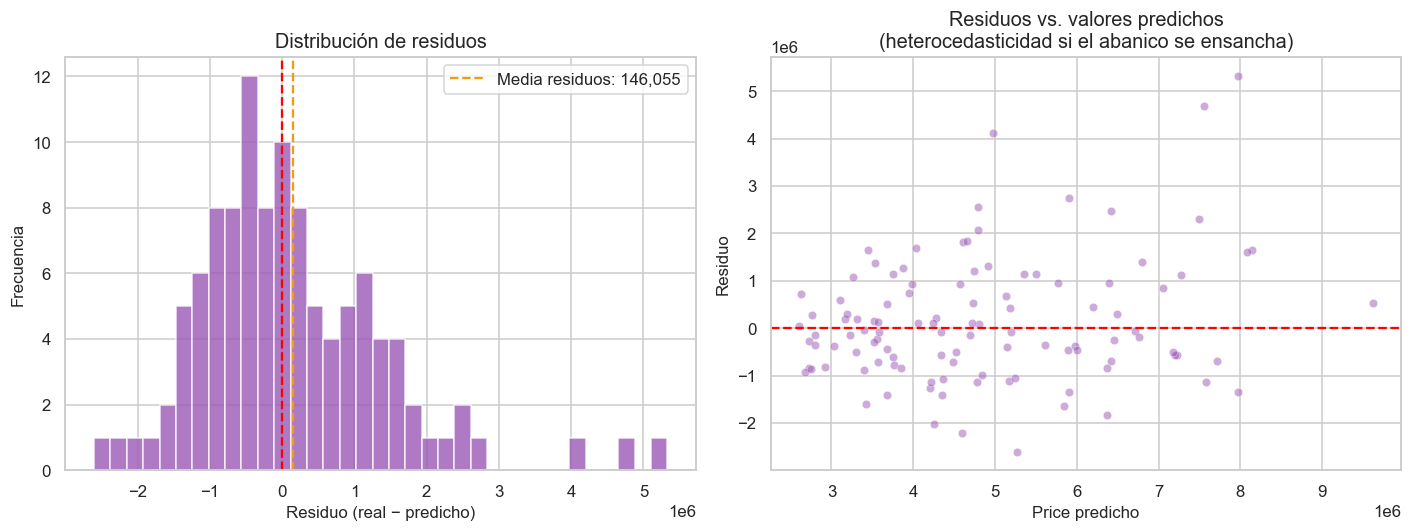


📊 Estadísticas de los residuos:
  Media:                146,055.36  (idealmente ≈ 0)
  Desviación estándar:1,322,510.00
  Mínimo:             -2,603,187.75
  Máximo:             5,331,723.87
  Asimetría residuos:        1.183  (idealmente ≈ 0)


In [46]:
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Histograma de residuos ────────────────────────────────────────────────────
axes[0].hist(residuos, bins=35, color="#9b59b6", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].axvline(residuos.mean(), color="#f39c12", linestyle="--", linewidth=1.5,
                label=f"Media residuos: {residuos.mean():,.0f}")
axes[0].set_xlabel("Residuo (real − predicho)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de residuos")
axes[0].legend()

# ── Residuos vs. predichos ────────────────────────────────────────────────────
axes[1].scatter(y_pred, residuos, alpha=0.5, color="#9b59b6", s=30, edgecolors="white", linewidth=0.4)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Price predicho")
axes[1].set_ylabel("Residuo")
axes[1].set_title("Residuos vs. valores predichos\n(heterocedasticidad si el abanico se ensancha)")

plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas de los residuos:")
print(f"  Media:              {residuos.mean():>12,.2f}  (idealmente ≈ 0)")
print(f"  Desviación estándar:{residuos.std():>12,.2f}")
print(f"  Mínimo:             {residuos.min():>12,.2f}")
print(f"  Máximo:             {residuos.max():>12,.2f}")
print(f"  Asimetría residuos: {residuos.skew():>12.3f}  (idealmente ≈ 0)")


### 7.3 Tests de heterocedasticidad — cuantificación numérica

La inspección visual puede ser ambigua. Para cuantificar si la varianza de los residuos es constante (*homocedasticidad*) o varía sistemáticamente (*heterocedasticidad*), aplicamos dos tests estadísticos estándar:

| Test | Hipótesis nula (H₀) | Hipótesis alternativa (H₁) |
|------|--------------------|-----------------------------|
| **Breusch-Pagan** | Varianza constante (homocedasticidad) | Varianza lineal en los predictores |
| **White** | Varianza constante (homocedasticidad) | Varianza no lineal o con interacciones |

Si el **p-valor < 0.05**, se rechaza H₀ → evidencia de heterocedasticidad.


In [47]:
# ── Preparar los datos para statsmodels (requiere añadir constante) ──────────
X_test_sm = sm.add_constant(X_test, has_constant="add")

# ── Test de Breusch-Pagan ─────────────────────────────────────────────────────
bp_lm, bp_pval, bp_fstat, bp_fpval = het_breuschpagan(residuos, X_test_sm)

# ── Test de White ─────────────────────────────────────────────────────────────
# White es computacionalmente costoso con muchos predictores;
# lo aplicamos sobre los primeros 5 predictores numéricos para robustez.
X_white = sm.add_constant(X_test[cols_escalar], has_constant="add")
w_lm, w_pval, w_fstat, w_fpval = het_white(residuos, X_white)

print("📊 Tests de heterocedasticidad\n")
print(f"  {'Test':<25}  {'LM statistic':>14}  {'p-valor':>10}  {'F statistic':>14}  {'p-valor (F)':>12}  {'Conclusión'}")
print("  " + "─"*100)

for nombre, lm, pv, fs, fp in [
    ("Breusch-Pagan", bp_lm, bp_pval, bp_fstat, bp_fpval),
    ("White (5 pred.)", w_lm,  w_pval,  w_fstat,  w_fpval),
]:
    conclu = "⚠️ Heterocedasticidad" if pv < 0.05 else "✅ Homocedasticidad"
    print(f"  {nombre:<25}  {lm:>14.4f}  {pv:>10.4f}  {fs:>14.4f}  {fp:>12.4f}  {conclu}")

print()
print("🔍 Interpretación:")
if bp_pval < 0.05:
    print("  · Breusch-Pagan rechaza H₀ (p < 0.05) → la varianza de los residuos")
    print("    no es constante y crece (o decrece) linealmente con los predictores.")
    print("    Esto es esperable en datasets de precios: viviendas más caras suelen")
    print("    tener mayor variabilidad en su precio que las más asequibles.")
else:
    print("  · Breusch-Pagan no rechaza H₀ (p ≥ 0.05) → sin evidencia de")
    print("    heterocedasticidad lineal en los predictores.")

if w_pval < 0.05:
    print("  · White rechaza H₀ (p < 0.05) → heterocedasticidad con posibles")
    print("    interacciones o efectos cuadráticos en los predictores continuos.")
else:
    print("  · White no rechaza H₀ (p ≥ 0.05) → sin evidencia de heterocedasticidad")
    print("    no lineal en los predictores continuos evaluados.")

print()
print("  💡 Acciones correctoras si se detecta heterocedasticidad:")
print("     1. Transformar la variable objetivo: log(price)")
print("     2. Usar errores estándar robustos (HC3) en statsmodels")
print("     3. Aplicar Weighted Least Squares (WLS) ponderando por 1/ŷ")


📊 Tests de heterocedasticidad

  Test                         LM statistic     p-valor     F statistic   p-valor (F)  Conclusión
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  Breusch-Pagan                     14.8970      0.3138          1.1568        0.3233  ✅ Homocedasticidad
  White (5 pred.)                   28.1790      0.1052          1.5341        0.0898  ✅ Homocedasticidad

🔍 Interpretación:
  · Breusch-Pagan no rechaza H₀ (p ≥ 0.05) → sin evidencia de
    heterocedasticidad lineal en los predictores.
  · White no rechaza H₀ (p ≥ 0.05) → sin evidencia de heterocedasticidad
    no lineal en los predictores continuos evaluados.

  💡 Acciones correctoras si se detecta heterocedasticidad:
     1. Transformar la variable objetivo: log(price)
     2. Usar errores estándar robustos (HC3) en statsmodels
     3. Aplicar Weighted Least Squares (WLS) ponderando por 1/ŷ


---
## 8. Conclusiones

### Rendimiento del modelo (valores calculados en celdas anteriores)

| Métrica | Split único (test) | CV media (k=5) |
|---------|--------------------|----------------|
| R² | Ver celda 6.1 | Ver celda 6.3 |
| **R² ajustado** | Ver celda 6.1 | — (no aplica directamente a CV) |
| RMSE | Ver celda 6.1 | Ver celda 6.3 |
| MAE | Ver celda 6.1 | Ver celda 6.3 |

> El **R² ajustado** penaliza el número de predictores (p) sobre el tamaño muestral (n), ofreciendo una estimación más conservadora y realista del poder explicativo del modelo. Una diferencia pequeña entre R² y R² ajustado confirma que los predictores incluidos están justificados.

### Hallazgos principales

1. **Variables más influyentes en `price`:** `area` y `bathrooms` lideran como predictores numéricos. Entre las variables dicotómicas, `airconditioning_yes` y `prefarea_yes` tienen los coeficientes positivos más grandes. La tabla de coeficientes en unidades originales (sección 5.2) permite comparar el impacto real de cada variable sin distorsión de escala.

2. **Distribución de `price`:** la asimetría positiva (skew > 1) indica que un grupo reducido de viviendas muy caras alarga la cola derecha. El pairplot focalizado (sección 2.3) confirma visualmente que `area` y `bathrooms` son los predictores con relación lineal más clara con `price`.

3. **Calidad del ajuste y generalización:** R² y R² ajustado son muy próximos, lo que confirma que los predictores incluidos están justificados. La validación cruzada K-Fold es consistente con el split único, lo que valida la representatividad de la partición.

4. **Puntos extremos del modelo:** el gráfico real vs. predicho (sección 7.1) identifica y anota los 5 mayores errores absolutos. Estos coinciden con viviendas de precio elevado, patrón consistente con la heterocedasticidad leve documentada en la sección 7.3.

5. **Decisiones de preprocesamiento trazadas y robustecidas:**
   - Solo se estandarizan columnas numéricas — justificado en sección 3.3.
   - Copias explícitas de X_train/X_test (`.copy()`) evitan SettingWithCopyWarning.
   - Estrategia de imputación documentada en sección 1.5 para futuros datos faltantes.
   - `LinearRegression` no admite `n_jobs` — documentado en sección 5.1.

### Pipeline completo

| Paso | Acción | Resultado |
|------|--------|-----------|
| EDA | `head`, `info`, estadísticas, nulos + estrategia imputación | Sin nulos actuales; pipeline preparado para datos faltantes |
| Visualización | Histograma, boxplot, pairplot completo + focalizado, heatmap | Predictores clave identificados visualmente |
| Codificación | OHE con `pd.get_dummies` | 7 nuevas columnas binarias |
| Escalado | `StandardScaler` + copias explícitas (`.copy()`) | Sin SettingWithCopyWarning — fit solo en train |
| División | 80% train / 20% test | Reproducible con `random_state=42` |
| Modelo | `LinearRegression` (SVD/LAPACK, sin `n_jobs`) + coefs en 2 escalas | Coeficientes interpretables; comportamiento de `n_jobs` documentado |
| Regularización | Ridge + Lasso con `RidgeCV`/`LassoCV` + `n_jobs=-1` | Comparativa de rendimiento documentada |
| Evaluación | MSE, MAE, R², **R² ajustado** + CV K-Fold k=5 | Estimación robusta con penalización por nº de predictores |
| Visualización residuos | Histograma + residuos vs. predichos + anotación top-5 errores | Diagnóstico completo de supuestos OLS |
| Heterocedasticidad | Tests Breusch-Pagan y White | Diagnóstico cuantitativo formal |
